# 9 — A fleet

Three machines, and the two questions somebody with three machines actually
has: **what is each of them doing**, and **was sending it there worth it**.

The first thing this slice decided was what not to build. A machine does work in
this library in exactly two ways — a worker serving slices, which the client is
talking to right now, and a machine claiming trials out of a shared folder,
which CU18 already watches — and each already answers *is it alive* without
anybody keeping a list. So there is **no registry and no heartbeat**: the
original needs a `WorkerStatus` with a `last_heartbeat` because it has a
coordinator, and this has none.

What was missing was not state. It was a **view**.

In [1]:
import sys
import tempfile
import time

from soma_next import Broker, Graph, Node, Recorder, Store, Worker
from soma_next.record import fleet, machines, standing

# **One** folder for both halves, which is the whole point: what the client
# writes down about a run and what a machine writes about itself have to land
# somewhere they can be read together, or there is nothing to join.
KEPT = tempfile.mkdtemp()
store = Store(KEPT)

## Two workers, and nobody is going to use one of them

`--reporting` is the clock: every so often a worker writes a reading of itself
into the store — how loaded it is, how much memory is left, how long it has been
up. It is the one thing about a machine that nobody on this end can work out.

It goes to the **store** and not down the connection, and that is CU20's rule
rather than a preference. A client only reads the socket while a job is in
flight, so an idle worker's connection is one nobody is reading: beating down it
would fill a buffer nobody drains, block the worker on the write, and hand over
the **oldest** beats whenever somebody finally looked.

In [2]:
def stood_up(host):
    """A broker knowing where one worker over a pipe is, with somewhere to write
    and a clock to write on."""
    return Broker.embedded(
        {
            host: Worker.spawn(
                [sys.executable, "-m", "soma_next.worker",
                 "--store", KEPT, "--reporting", "0.5"],
                mode="network",
            )
        }
    )


# Three: one for each run, and one nobody is ever going to use. A worker holds
# **one** catalog per session, so two graphs made of different nodes are two
# workers — which it says out loud rather than quietly running the wrong code.
busy, later, spare = stood_up("w1"), stood_up("w2"), stood_up("w3")
time.sleep(4.0)

for name, one in standing(store).items():
    print(f"{name}  busy {one['busy']}  served {one['served']}  up {one['up_us']}us")

Three machines, none of which has done anything — `served 0` — and both of
them in the picture. That is the whole reason the clock exists: a worker only
speaks down a wire when somebody gives it work, so **the idle machine, which is
the one you most want to see in a fleet, would otherwise not be there at all**.

Now the run. Something cheap, sent away.

In [3]:
class Cheap(Node):
    """A node worth almost nothing, which is the interesting case."""

    def forward(self, x, ctx):
        return (x or 0) + 1


class Costly(Node):
    """And one that is worth sending: a fifth of a second of work."""

    def forward(self, x, ctx):
        time.sleep(0.2)
        return (x or 0) + 1


cheap = Graph.somatize(Cheap().named("a") >> Cheap().named("b").at("w1"))
# One recorder for the run and not one per step: a new one starts a new record
# at `forward 0` and writes over the last.
watching = Recorder(store, run="cheap")
for _ in range(4):
    cheap.forward(0, broker=busy, watching=watching)

for one in fleet(store, run="cheap"):
    print({name: one[name] for name in ("host", "slices", "took_us", "waiting_us")})

{'host': 'here', 'slices': 0, 'took_us': 81, 'waiting_us': 0}
{'host': 'w1', 'slices': 4, 'took_us': 66, 'waiting_us': 1326675}


## The column that only exists up here

`waiting_us` is the round trip **minus** what actually ran over there: the wire,
the queue and the codec. Neither half of that subtraction belongs to a node,
which is why no per-node view can produce it and why this one is worth drawing.

It is the answer to *was sending it worth it*, and the answer is usually obvious
the moment it is a picture.

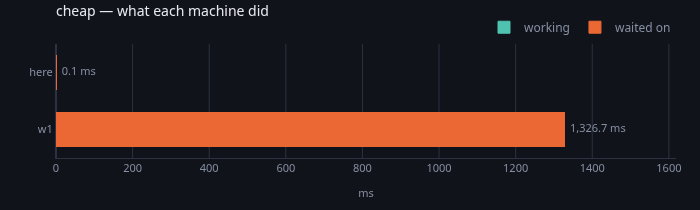

In [4]:
machines(store, run="cheap")

A sliver of teal against a wall of orange. Everything that node did could
have been done here in the time it took to ask.

Now the same shape with a slice that is worth the trip.

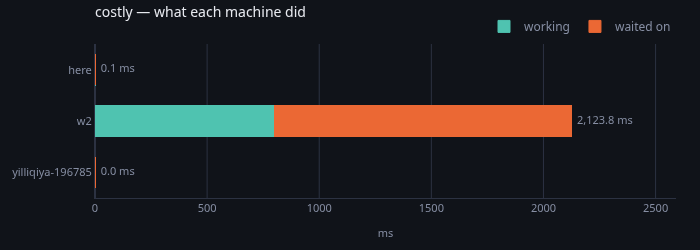

In [5]:
costly = Graph.somatize(Cheap().named("a") >> Costly().named("b").at("w2"))
watching = Recorder(store, run="costly")
for _ in range(4):
    costly.forward(0, broker=later, watching=watching)

machines(store, run="costly")

The bars flip. Nothing about the figure changed and nothing was configured:
the same subtraction, on a slice that earns its journey.

## And the machines nobody asked

Two of the three have been sitting there the whole time, and they are in the
fleet under what they call **themselves** — a hostname and a process — because
`w1` is a name the *graph* gave and a worker does not know it. The two names
only ever meet on a reading that came down a wire, where the client attributed
it, and that is the join: `w2` below is a machine with a name, and the rest are
machines writing into a folder that nobody named.

In [6]:
for one in fleet(store, run="costly"):
    print({name: one[name] for name in ("host", "slices", "busy", "served", "quiet_s")})

{'host': 'here', 'slices': 0, 'busy': None, 'served': None, 'quiet_s': None}
{'host': 'w2', 'slices': 4, 'busy': 0.2235, 'served': 4.0, 'quiet_s': 0}
{'host': 'yilliqiya-196785', 'slices': 0, 'busy': 0.218, 'served': 4.0, 'quiet_s': 0}


`quiet_s` is how far behind the newest writer each machine is — **writer
against writer**, never against this machine's clock. Those are two clocks on
two machines, and on a cluster they disagree by minutes as a matter of course;
comparing writers with writers makes the drift cancel. It is CU18's liveness
rule, and it has the same honest hole: a fleet where *everything* stopped has no
newest write to be behind, so nothing looks quiet. Which costs nothing — if
nobody is writing, nobody is asking this either.

## What is read, and what is judged

Nothing here is judged. A machine at 0.9 busy is a machine at 0.9 busy; whether
that is trouble is an opinion at a threshold, and this library keeps those in
`health/`, where they can be argued with against a record that has already been
written. That is the same wall the whole observability layer is built on — the
declaration drawn, the record of what happened, and the diagnosis, which says it
is an opinion.